Hypothesis testing & PRC of simple de novo simulation.

In [1]:
#imports
import scMPRAforge as scm
import pandas as pd
import numpy as np
from dask.distributed import Client, LocalCluster

2025-09-22 15:35:23.516393: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-22 15:35:24.425836: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/Code-Server/4.17.0/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [2]:
#autoreload
%load_ext autoreload
%autoreload 2

In [3]:
#set up cluster
local=True

if local:
    cluster=LocalCluster(memory_limit='4GB',n_workers=3,threads_per_worker=4,)
    client=Client(cluster)
else:
    from dask_jobqueue import SLURMCluster
    from dask.distributed import Client

    cluster=SLURMCluster(
        cores=2,#cores per slurm job
        memory="64G",#memory per slurm job
        processes=1,#dask workers
        job_extra_directives=["-p ycga", 
            f"--job-name=simclust_worker",
            f"--time=3:00:00",
            f"--output=slave_%j.out"]
    )

    cluster.scale(jobs=6)

    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )


In [4]:
#load sim & hypo test
data_root="/gpfs/gibbs/pi/reilly/tabula_data"

#hypothesis_set=scm.HypothesisSet.from_tsv(f"{data_root}/simulated/activity_de_novo_hypotheses.tsv")
hypothesis_set=scm.HypothesisSet.from_tsv(f"{data_root}/simulated/activity_de_novo_hypotheses.tsv")

In [5]:
de_novo_sim=None
first_time=False
if first_time:
    de_novo_sim=scm.de_novo_simulation.load(client,data_root,"simulated/activity_de_novo")
    de_novo_sim._test_replicate(client,hypothesis_set,test="wald",index=0)
    de_novo_sim._test_replicate(client,hypothesis_set,test="mwu",index=0)
    de_novo_sim.save(data_root,"simulated/activity_de_novo_and_results")
else:
    de_novo_sim=scm.de_novo_simulation.load(client,data_root,"simulated/activity_de_novo_and_results")

In [7]:
de_novo_sim.results

{'mwu': [<Future: finished, type: scMPRAforge.core.ResultSet, key: lambda-f175225dd52c2a997d516eae30f5577b>],
 'wald': [<Future: finished, type: scMPRAforge.core.ResultSet, key: lambda-427f34ae7f25d5fc481feb98131876ac>]}

In [8]:
de_novo_sim.crosstab(test="wald",index=0)

reject_null,False,True
gt_null,,
False,81,1585
True,3925,52


In [9]:
de_novo_sim.crosstab(test="mwu",index=0)

reject_null,False,True
gt_null,,
False,91,1575
True,3918,29


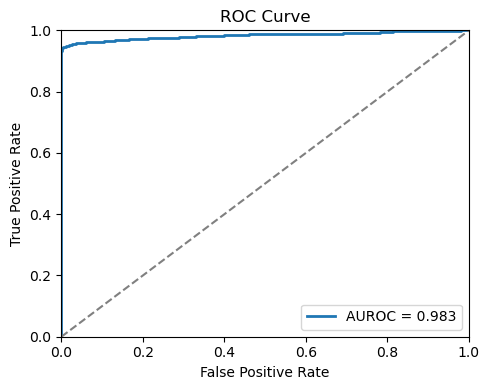

In [15]:
de_novo_sim.roc(test="mwu",index=0)

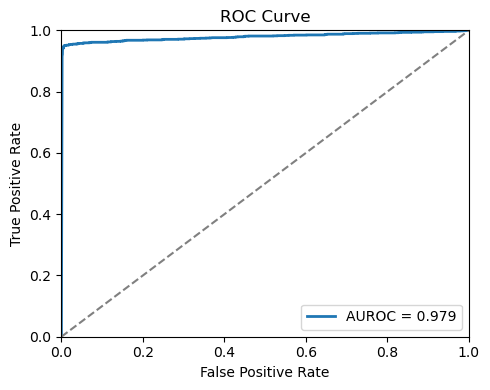

In [14]:
roc(de_novo_sim,test="wald",index=0)

In [22]:
merged=de_novo_sim._merge_in_ground_truth(test="mwu",index=0)
df=merged.drop(columns=["meta"])
mwu_na=df[df.isna().any(axis=1)]


In [23]:
merged=de_novo_sim._merge_in_ground_truth(test="wald",index=0)
df=merged.drop(columns=["meta"])
wald_na=df[df.isna().any(axis=1)]

In [24]:
mwu_na

,comparison_CRE,reference_CRE,comparison_cell_type,reference_cell_type,test_statistic,p_value,fold_change,flattened,ref_mean,comp_mean,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
47,inactive_15,reference,neuron,neuron,NaN,NaN,NaN,True,0.0330660219604515,NaN,mwu,1.0,0.072776,0.072776,1.0,True,False
48,inactive_16,reference,reference,reference,NaN,NaN,NaN,True,0.05159606248380477,NaN,mwu,1.0,0.072776,0.072776,1.0,True,False
50,inactive_16,reference,neuron,neuron,NaN,NaN,NaN,True,0.0330660219604515,NaN,mwu,1.0,0.072776,0.072776,1.0,True,False
59,inactive_19,reference,neuron,neuron,NaN,NaN,NaN,True,0.0330660219604515,NaN,mwu,1.0,0.072776,0.072776,1.0,True,False
98,inactive_32,reference,neuron,neuron,NaN,NaN,NaN,True,0.0330660219604515,NaN,mwu,1.0,0.072776,0.072776,1.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5465,inactive_465,inactive_465,neuron,blood,NaN,NaN,NaN,True,0.03783092349812622,NaN,mwu,1.0,0.072776,0.072776,1.0,True,False
5472,inactive_472,inactive_472,neuron,blood,NaN,NaN,NaN,True,0.02773882443160769,NaN,mwu,1.0,0.072776,0.072776,1.0,True,False
5483,inactive_483,inactive_483,neuron,blood,NaN,NaN,NaN,True,0.034054240495138055,NaN,mwu,1.0,0.072776,0.072776,1.0,True,False
5492,inactive_492,inactive_492,neuron,blood,NaN,NaN,NaN,True,0.07095740331291234,NaN,mwu,1.0,0.072776,0.072776,1.0,True,False


In [28]:
wald_na

,comparison_CRE,reference_CRE,comparison_cell_type,reference_cell_type,test_statistic,p_value,fold_change,flattened,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
47,inactive_15,reference,neuron,neuron,NaN,NaN,NaN,True,wald,1.0,0.072776,0.072776,1.0,True,False
48,inactive_16,reference,reference,reference,NaN,NaN,NaN,True,wald,1.0,0.072776,0.072776,1.0,True,False
50,inactive_16,reference,neuron,neuron,NaN,NaN,NaN,True,wald,1.0,0.072776,0.072776,1.0,True,False
59,inactive_19,reference,neuron,neuron,NaN,NaN,NaN,True,wald,1.0,0.072776,0.072776,1.0,True,False
98,inactive_32,reference,neuron,neuron,NaN,NaN,NaN,True,wald,1.0,0.072776,0.072776,1.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5465,inactive_465,inactive_465,neuron,blood,NaN,NaN,NaN,True,wald,1.0,0.072776,0.072776,1.0,True,False
5472,inactive_472,inactive_472,neuron,blood,NaN,NaN,NaN,True,wald,1.0,0.072776,0.072776,1.0,True,False
5483,inactive_483,inactive_483,neuron,blood,NaN,NaN,NaN,True,wald,1.0,0.072776,0.072776,1.0,True,False
5492,inactive_492,inactive_492,neuron,blood,NaN,NaN,NaN,True,wald,1.0,0.072776,0.072776,1.0,True,False


In [25]:
merged

,comparison_CRE,reference_CRE,comparison_cell_type,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,test_type,bh_p,comparison_truth,reference_truth,gt_effect_size,gt_null,reject_null
0,inactive_0,reference,reference,reference,<NA>,-0.509631,0.610310,0.797788,True,wald,0.902603,0.072776,0.072776,1.000000,True,False
1,inactive_0,reference,blood,blood,<NA>,-2.020367,0.043345,0.508335,True,wald,0.148274,0.072776,0.072776,1.000000,True,False
2,inactive_0,reference,neuron,neuron,<NA>,-0.027246,0.978263,0.986075,True,wald,1.000000,0.072776,0.072776,1.000000,True,False
3,inactive_1,reference,reference,reference,<NA>,-0.609843,0.541966,0.744003,True,wald,0.863639,0.072776,0.072776,1.000000,True,False
4,inactive_1,reference,blood,blood,<NA>,-0.922708,0.356159,0.733632,True,wald,0.714259,0.072776,0.072776,1.000000,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,active_495,active_495,neuron,blood,<NA>,1.790007,0.073453,1.333976,True,wald,0.233554,59.957048,46.149411,1.299194,False,False
5996,active_496,active_496,neuron,blood,<NA>,-0.181793,0.855745,0.959906,True,wald,1.000000,77.648630,77.648630,1.000000,True,False
5997,active_497,active_497,neuron,blood,<NA>,0.378998,0.704690,1.175146,True,wald,0.942308,24.196560,24.196560,1.000000,True,False
5998,active_498,active_498,neuron,blood,<NA>,1.750058,0.080108,1.524901,True,wald,0.250861,5.540466,5.540466,1.000000,True,False


In [29]:
cols = ["comparison_CRE", "reference_CRE",
        "comparison_cell_type", "reference_cell_type"]

# Convert each row into a tuple so we can compare sets
set1 = set(map(tuple, wald_na[cols].values))
set2 = set(map(tuple, mwu_na[cols].values))

# Venn diagram info
only_df1 = set1 - set2
only_df2 = set2 - set1
both     = set1 & set2

print("Unique to df1:", len(only_df1))
print("Unique to df2:", len(only_df2))
print("Shared:", len(both))

Unique to df1: 3
Unique to df2: 33
Shared: 354


In [27]:
hypothesis_set.df

,comparison_CRE,reference_CRE,comparison_cell_type,reference_cell_type,meta
0,inactive_0,reference,reference,reference,<NA>
1,inactive_0,reference,blood,blood,<NA>
2,inactive_0,reference,neuron,neuron,<NA>
3,inactive_1,reference,reference,reference,<NA>
4,inactive_1,reference,blood,blood,<NA>
...,...,...,...,...,...
5995,active_495,active_495,neuron,blood,<NA>
5996,active_496,active_496,neuron,blood,<NA>
5997,active_497,active_497,neuron,blood,<NA>
5998,active_498,active_498,neuron,blood,<NA>


In [30]:
cluster.close()
client.close()

2025-09-22 15:23:33,686 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:37621' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-34eb92f4586eba6b56932e09d51ee0e9'} (stimulus_id='handle-worker-cleanup-1758569013.6864846')
2025-09-22 15:23:33,688 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:34613' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-fd31910fdd3a0857da0353d0e918771d', 'lambda-d627ab289d6a27a935b5ac16c39aae79'} (stimulus_id='handle-worker-cleanup-1758569013.6881008')
2025-09-22 15:23:33,689 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:35035' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-5eab54c2b7f20d677e6efc5ed156785a', 'lambda-5d3078d3127d60f638f6f31daf73aad3'} (stimulus_id='handle-worker-cleanup-1758569013.689261')
